# 05 Error Analysis & Informality Sensitivity (H2)

Answers **H2**: does the LLM advantage (if any) grow on slangier / more informal posts?

Also covers adjacent-class confusion and a qualitative error deep-dive.

**Requires:** all encoder checkpoints in `results/runs/`, `data/vocab.json`, `data/glove_embeddings.pt`

**LLM predictions:** loaded from `results/runs/<run_name>/test_predictions.csv` if available; cells are skipped gracefully if not yet present.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import torch
from torch.utils.data import DataLoader

sys.path.insert(0, '..')

from src.data import load_splits
from src.slang import add_informality_score, bin_macro_f1
from src.shap_explain import load_model, get_predictions
from src.lstm_baseline import BiLSTMModel, TextDataset, collate_batch

RUNS_DIR    = Path('../results/runs')
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

_, _, test_df = load_splits()
print(f'Test set: {len(test_df)} rows')

c:\Users\Nolan\anaconda3\envs\capstone\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cpu
Test set: 1041 rows


## 1 — Score test set for informality

Adds `informality_score` (0–∞) and `informality_bin` (low/mid/high tertiles) to the test DataFrame.
Pass `glove_path` if GloVe is available for the 4-component score; otherwise 3-component is used.

In [2]:
test_df = add_informality_score(
    test_df,
    glove_path=DATA_DIR / 'glove.6B.300d.txt',
    include_components=True,
)

print(test_df[['informality_score', 'informality_bin']].describe())
print()
print(test_df['informality_bin'].value_counts().sort_index())

# Spot-check: highest-informality posts
print('\n── Top 5 most informal posts ──')
for _, row in test_df.nlargest(5, 'informality_score').iterrows():
    print(f"  [{row['informality_bin']}  score={row['informality_score']:.2f}]  {row['text'][:100]}")

19:36:55  INFO      src.slang — Loading GloVe vocabulary from ..\data\glove.6B.300d.txt ...
19:36:57  INFO      src.slang — GloVe vocabulary size: 400,000
19:36:57  INFO      src.slang — Computing informality scores for 1,041 posts ...
19:36:57  INFO      src.slang — Informality bins — low: 347  mid: 349  high: 345  (score range 0.000–1.154)


       informality_score
count        1041.000000
mean            0.156324
std             0.122069
min             0.000000
25%             0.086957
50%             0.142857
75%             0.200000
max             1.153846

informality_bin
high    345
low     347
mid     349
Name: count, dtype: int64

── Top 5 most informal posts ──
  [high  score=1.15]  FINALLY!!! HOW CAN I HELP?!?!?!!! SAVE OUR CHILDREN FROM SELF- DESTRUCTION! ...GREAT JOB!
  [high  score=1.08]  QUEEN MITSKI IM SO DEPRESSED RN PLS RELEASE UR NEW MUSIC EARLY
  [high  score=1.05]  YESSS I JUST HAVE TO KEEP GRINDING MORE PRIMOS I HAVE GURANTEE SO NO MATTER WHAT IM NOT MISSING HER 
  [high  score=1.04]  I HATE WHEN IM TOO DEPRESSED TO EVEN LOVE PERFUME EVEN THO I KNOW IT SMELLS GOOD...DEPRESSION REALLY
  [high  score=1.00]  I’m tired.


## 2 — Generate predictions

Runs inference for each model using the saved checkpoints.
Results are cached to `test_predictions.csv` so this only runs once.

In [4]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
login(token=os.environ.get("HF_TOKEN"))

def load_or_run_encoder(run_dir: str, model_name: str, cache_name: str) -> np.ndarray:
    """Load cached predictions or run inference and cache them."""
    cache = RUNS_DIR / run_dir / 'test_predictions.csv'
    if cache.exists():
        preds = pd.read_csv(cache)['pred_id'].values
        print(f'  Loaded cached predictions: {run_dir} ({len(preds)} rows)')
        return preds
    run_path = RUNS_DIR / run_dir
    if not run_path.exists():
        print(f'  Skipping {run_dir} — checkpoint not found')
        return None
    print(f'  Running inference: {run_dir} ...')
    model, tokenizer, dev = load_model(run_path, model_name, device)
    preds, probs = get_predictions(model, tokenizer, test_df['text'].tolist(), dev)
    pd.DataFrame({
        'pred_id': preds,
        **{f'prob_{i}': probs[:, i] for i in range(4)}
    }).to_csv(cache, index=False)
    print(f'  Cached to {cache}')
    return preds


def load_or_run_lstm() -> np.ndarray:
    """Load cached LSTM predictions or run inference from best.pt."""
    cache = RUNS_DIR / 'lstm' / 'test_predictions.csv'
    if cache.exists():
        preds = pd.read_csv(cache)['pred_id'].values
        print(f'  Loaded cached LSTM predictions ({len(preds)} rows)')
        return preds
    ckpt_path = RUNS_DIR / 'lstm' / 'best.pt'
    vocab_path = DATA_DIR / 'vocab.json'
    emb_path   = DATA_DIR / 'glove_embeddings.pt'
    if not all(p.exists() for p in [ckpt_path, vocab_path, emb_path]):
        print('  Skipping LSTM — best.pt / vocab.json / glove_embeddings.pt not found')
        return None
    print('  Running LSTM inference ...')
    with open('../configs/lstm.yaml') as f:
        cfg = yaml.safe_load(f)
    word2idx = json.loads(vocab_path.read_text(encoding='utf8'))['word2idx']
    pad_idx   = word2idx.get('<pad>', 0)
    emb_tensor = torch.load(str(emb_path), map_location='cpu')
    lstm_model = BiLSTMModel(emb_tensor, cfg, pad_idx=pad_idx).to(device)
    ckpt = torch.load(str(ckpt_path), map_location=device)
    lstm_model.load_state_dict(ckpt['model_state'])
    lstm_model.eval()
    test_ds = TextDataset(test_df, word2idx, max_len=cfg.get('max_length', 128))
    loader  = DataLoader(test_ds, batch_size=64, shuffle=False,
                         collate_fn=lambda b: collate_batch(b, pad_idx=pad_idx))
    preds = []
    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            logits = lstm_model(input_ids.to(device), lengths.to(device))
            preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    preds = np.array(preds)
    pd.DataFrame({'pred_id': preds}).to_csv(cache, index=False)
    print(f'  Cached to {cache}')
    return preds


print('Generating / loading predictions ...')
all_preds = {}

all_preds['LSTM'] = load_or_run_lstm()
all_preds['MentalBERT'] = load_or_run_encoder('mentalbert', 'mental/mental-bert-base-uncased', 'mentalbert')
all_preds['RoBERTa']    = load_or_run_encoder('roberta',    'roberta-base',                   'roberta')

# LLMs — loaded from JSONL logs
LABEL2ID_MAP = {'minimum': 0, 'mild': 1, 'moderate': 2, 'severe': 3}
LLM_LOGS_DIR = Path('../results/llm_logs')

def load_llm_preds(log_dir: str, variant: str = 'chain_of_thought') -> np.ndarray | None:
    log_path = LLM_LOGS_DIR / log_dir
    files = sorted(log_path.glob(f'*{variant}*.jsonl'))
    if not files:
        return None
    records = {}
    for fp in files:
        for line in open(fp, encoding='utf-8'):
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                idx = obj.get('index')
                if idx is not None:
                    records[int(idx)] = obj
            except json.JSONDecodeError:
                continue
    if not records:
        return None
    preds = np.full(len(test_df), -1, dtype=int)
    for idx, rec in records.items():
        if 0 <= idx < len(test_df):
            preds[idx] = LABEL2ID_MAP.get(rec.get('pred_label', ''), -1)
    return preds

for log_dir, label in [('gpt5', 'GPT-5.4-mini CoT'), ('gemini3', 'Gemini 3 Flash CoT')]:
    preds = load_llm_preds(log_dir, 'chain_of_thought')
    if preds is not None:
        all_preds[label] = preds
        n_valid = int((preds >= 0).sum())
        print(f'  Loaded {label}: {n_valid}/{len(preds)} valid predictions')
    else:
        print(f'  {label} — JSONL not found, run run_llm_eval.py first')

# Drop any that failed to load
all_preds = {k: v for k, v in all_preds.items() if v is not None}
print(f'\nModels ready: {list(all_preds.keys())}')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
19:39:52  WARNING   src.shap_explain — trainer_state.json not found — using last checkpoint: ..\results\runs\mentalbert\checkpoint-2084
19:39:52  INFO      src.shap_explain — Loading checkpoint: ..\results\runs\mentalbert\checkpoint-2084  →  device=cpu


Generating / loading predictions ...
  Loaded cached LSTM predictions (1041 rows)
  Running inference: mentalbert ...


c:\Users\Nolan\anaconda3\envs\capstone\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nolan\.cache\huggingface\hub\models--mental--mental-bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3846.39it/s]
19:41:33  WARNING   src.shap_

  Cached to ..\results\runs\mentalbert\test_predictions.csv
  Running inference: roberta ...


c:\Users\Nolan\anaconda3\envs\capstone\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Nolan\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3845.26it/s]


  Cached to ..\results\runs\roberta\test_predictions.csv
  Loaded GPT-5.4-mini CoT: 1041/1041 valid predictions
  Loaded Gemini 3 Flash CoT: 1041/1041 valid predictions

Models ready: ['LSTM', 'MentalBERT', 'RoBERTa', 'GPT-5.4-mini CoT', 'Gemini 3 Flash CoT']


## 3 — H2: Macro-F1 by informality bin

If the LLM advantage is real and driven by slang/register, Δ(LLM − MentalBERT) should grow from low → mid → high informality.

bin                   high     low     mid
model                                     
GPT-5.4-mini CoT    0.6228  0.6160  0.5718
Gemini 3 Flash CoT  0.5796  0.5655  0.5149
LSTM                0.5090  0.5526  0.5075
MentalBERT          0.7115  0.6569  0.6574
RoBERTa             0.6882  0.6753  0.6710


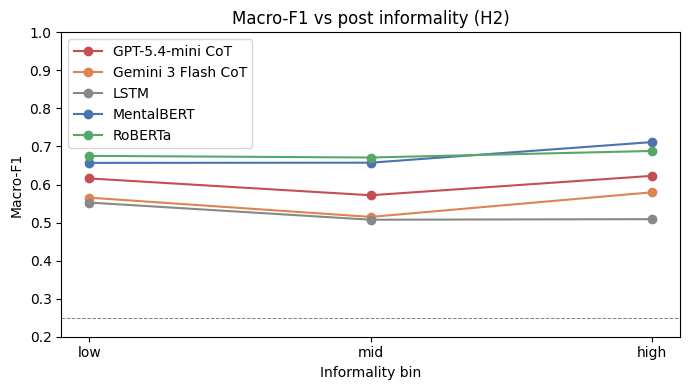

Saved -> ..\results\figures\h2_informality_bins.png


In [5]:
bin_results = pd.concat([
    bin_macro_f1(test_df, preds, name)
    for name, preds in all_preds.items()
])

print(bin_results.pivot(index='model', columns='bin', values='macro_f1').to_string())

# Line plot
fig, ax = plt.subplots(figsize=(7, 4))
colours = {'LSTM': '#888888', 'MentalBERT': '#4C72B0', 'RoBERTa': '#55A868',
           'GPT-5.4-mini CoT': '#C44E52', 'Gemini 3 Flash CoT': '#DD8452'}
BIN_ORDER = ['low', 'mid', 'high']

for model_name, grp in bin_results.groupby('model'):
    grp = grp.set_index('bin').reindex(BIN_ORDER)
    ax.plot(BIN_ORDER, grp['macro_f1'], marker='o',
            label=model_name, color=colours.get(model_name))

ax.set_xlabel('Informality bin')
ax.set_ylabel('Macro-F1')
ax.set_title('Macro-F1 vs post informality (H2)')
ax.legend()
ax.set_ylim(0.2, 1.0)
ax.axhline(0.25, color='gray', linewidth=0.7, linestyle='--')
plt.tight_layout()
out = FIGURES_DIR / 'h2_informality_bins.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved -> {out}')

## 4 — H2 verdict

Pre-registered rule: LLM slang-edge holds only if Δ(LLM − MentalBERT) is **monotonically increasing** across bins AND positive in the high bin.

In [6]:
if 'MentalBERT' not in all_preds:
    print('MentalBERT predictions not loaded — skipping H2 verdict.')
else:
    mb_f1 = bin_results[bin_results['model'] == 'MentalBERT'].set_index('bin')['macro_f1']
    llm_candidates = [m for m in all_preds if m not in ('LSTM', 'MentalBERT', 'RoBERTa')]

    if not llm_candidates:
        print('No LLM results yet — H2 verdict pending.')
    else:
        for llm in llm_candidates:
            llm_f1 = bin_results[bin_results['model'] == llm].set_index('bin')['macro_f1']
            deltas = {b: round(llm_f1[b] - mb_f1[b], 4) for b in BIN_ORDER if b in llm_f1.index and b in mb_f1.index}
            monotone = all(deltas[BIN_ORDER[i]] <= deltas[BIN_ORDER[i+1]] for i in range(len(BIN_ORDER)-1) if BIN_ORDER[i] in deltas and BIN_ORDER[i+1] in deltas)
            positive_high = deltas.get('high', -1) > 0
            verdict = 'HOLDS' if (monotone and positive_high) else 'FAILS'
            print(f'{llm} vs MentalBERT:')
            for b, d in deltas.items():
                print(f'  {b}: Δ={d:+.4f}')
            print(f'  Monotone: {monotone}  |  Positive in high bin: {positive_high}  |  H2 {verdict}\n')

GPT-5.4-mini CoT vs MentalBERT:
  low: Δ=-0.0409
  mid: Δ=-0.0856
  high: Δ=-0.0887
  Monotone: False  |  Positive in high bin: False  |  H2 FAILS

Gemini 3 Flash CoT vs MentalBERT:
  low: Δ=-0.0914
  mid: Δ=-0.1425
  high: Δ=-0.1319
  Monotone: False  |  Positive in high bin: False  |  H2 FAILS



## 5 — Adjacent-class confusion

For each model: what fraction of errors are adjacent (mild↔moderate, moderate↔severe) vs non-adjacent?
Adjacent errors are more forgivable clinically than e.g. minimum↔severe.

In [7]:
true_labels = test_df['label_id'].values
rows = []
for name, preds in all_preds.items():
    wrong_mask = preds != true_labels
    n_wrong = wrong_mask.sum()
    if n_wrong == 0:
        continue
    diff = np.abs(preds[wrong_mask].astype(int) - true_labels[wrong_mask].astype(int))
    rows.append({
        'Model':          name,
        'Total errors':   int(n_wrong),
        'Adjacent (|d|=1)':  int((diff == 1).sum()),
        'Skip-one (|d|=2)':  int((diff == 2).sum()),
        'Opposite (|d|=3)':  int((diff == 3).sum()),
        '% adjacent':     round(100 * (diff == 1).mean(), 1),
    })

df_conf = pd.DataFrame(rows).set_index('Model')
df_conf

,Total errors,Adjacent (|d|=1),Skip-one (|d|=2),Opposite (|d|=3),% adjacent
Model,,,,,
LSTM,401,290,81,30,72.3
MentalBERT,253,202,40,11,79.8
RoBERTa,259,209,42,8,80.7
GPT-5.4-mini CoT,295,218,55,22,73.9
Gemini 3 Flash CoT,328,233,74,21,71.0


## 6 — Error deep-dive: high-informality failures

Posts in the **high** informality bin where MentalBERT is wrong.
These are the candidates most likely to show LLM advantage.

In [8]:
ID2LABEL = {0: 'minimum', 1: 'mild', 2: 'moderate', 3: 'severe'}

if 'MentalBERT' not in all_preds:
    print('MentalBERT predictions not loaded.')
else:
    mb_preds = all_preds['MentalBERT']
    high_mask  = test_df['informality_bin'].values == 'high'
    wrong_mask = mb_preds != true_labels
    focus = test_df[high_mask & wrong_mask].copy()
    focus['true']  = [ID2LABEL[l] for l in true_labels[high_mask & wrong_mask]]
    focus['mb_pred'] = [ID2LABEL[p] for p in mb_preds[high_mask & wrong_mask]]

    # Add other model predictions where available
    focus_idx = focus.index
    for name, preds in all_preds.items():
        if name == 'MentalBERT':
            continue
        focus[name] = [ID2LABEL[preds[i]] for i in np.where(high_mask & wrong_mask)[0]]

    print(f'High-informality MentalBERT failures: {len(focus)} posts\n')
    for _, row in focus.head(10).iterrows():
        print(f"true={row['true']:<10} mb={row['mb_pred']:<10} ", end='')
        for name in all_preds:
            if name not in ('MentalBERT',) and name in row:
                print(f"{name.split()[0]}={row[name]:<10}", end='')
        print(f"score={row['informality_score']:.2f}")
        print(f"  {row['text'][:120]}")
        print()

High-informality MentalBERT failures: 68 posts

true=moderate   mb=severe     LSTM=severe    RoBERTa=severe    GPT-5.4-mini=severe    Gemini=severe    score=0.24
  Having has an impact on every single piece of my life. I have to be careful about EVERYTHING. So no...I can't pretend I 

true=mild       mb=moderate   LSTM=moderate  RoBERTa=moderate  GPT-5.4-mini=mild      Gemini=mild      score=0.23
  Injecting at least 500ml of caffeine in my body on a daily and stopping it cold turkey. It’s been 3 days -My Body Hurts 

true=minimum    mb=mild       LSTM=mild      RoBERTa=mild      GPT-5.4-mini=minimum   Gemini=mild      score=0.23
  Idk what the communite says. I think of restricting a lot as high res lol. But- coffee / tea has been my go to. Also my 

true=severe     mb=moderate   LSTM=moderate  RoBERTa=moderate  GPT-5.4-mini=minimum   Gemini=mild      score=0.26
  I've tried getting new glasses, but that didn't help. Blood work came back fine. I have tried medication but only helped



## 7 — Informality breakdown by platform

Does Twitter or Reddit skew toward higher informality? And does the per-platform performance gap change across bins?

In [9]:
print('Informality bin distribution by platform:')
print(pd.crosstab(test_df['informality_bin'], test_df['source'], normalize='columns').round(3))

# Per-platform macro-F1 within each informality bin for MentalBERT
if 'MentalBERT' in all_preds:
    from sklearn.metrics import f1_score
    rows = []
    for src in ('twitter', 'reddit'):
        for b in BIN_ORDER:
            mask = (test_df['source'].values == src) & (test_df['informality_bin'].values == b)
            if mask.sum() < 5:
                continue
            f1 = f1_score(true_labels[mask], all_preds['MentalBERT'][mask],
                          average='macro', zero_division=0)
            rows.append({'source': src, 'bin': b, 'n': int(mask.sum()), 'macro_f1': round(f1, 4)})
    print('\nMentalBERT macro-F1 by platform × informality bin:')
    print(pd.DataFrame(rows).pivot(index='source', columns='bin', values='macro_f1').to_string())

Informality bin distribution by platform:
source           reddit  twitter
informality_bin                 
high              0.217    0.350
low               0.217    0.352
mid               0.566    0.298

MentalBERT macro-F1 by platform × informality bin:
bin        high     low     mid
source                         
reddit   0.4607  0.3721  0.4364
twitter  0.7503  0.7025  0.7510
